## Task 5

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # prevents OpenMP from crashing when multiple libs are loaded 

import sys
import pickle
import numpy as np
from pathlib import Path
from PIL import Image
import time
from collections import Counter
from collections import defaultdict

# Add repo root to path
REPO_ROOT = Path(".").resolve().parent
sys.path.append(str(REPO_ROOT))

# Anchor everything to wherever this notebook is sitting
BASE_DIR = REPO_ROOT
DATA_DIR = BASE_DIR / "multi_image_identities"
GALLERY_DIR = DATA_DIR / "multi_image_gallery" # reference images we search against
PROBE_DIR = DATA_DIR / "probe" # query images we're trying to identify

print("Setup complete!")

Setup complete!


In [2]:
from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce

pre = Preprocessing(image_size=224)
model_vgg = Embedding(pretrained="vggface2", device=pre.device)

# Build gallery embeddings and track file paths alongside labels (found this useful for error analysis)
print("Building gallery embeddings...")
gallery_embs = []
gallery_labels = []
gallery_paths = [] # keep paths so we can trace failures back to specific images

for identity_dir in sorted(GALLERY_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    identity = identity_dir.name
    for img_path in sorted(identity_dir.glob("*.jpg")):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        emb = model_vgg.encode(tensor).astype(np.float32)
        gallery_embs.append(emb)
        gallery_labels.append(identity)
        gallery_paths.append(img_path)

# Stack into a single matrix -> shape: (total_gallery_images, 512)
gallery_embs = np.vstack(gallery_embs)
print(f"Gallery: {gallery_embs.shape}")

# Build probe embeddings the same way
print("Building probe embeddings...")
probe_embs = []
probe_labels = []
probe_paths = []

for identity_dir in sorted(PROBE_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    identity = identity_dir.name
    for img_path in identity_dir.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        emb = model_vgg.encode(tensor).astype(np.float32)
        probe_embs.append(emb)
        probe_labels.append(identity)
        probe_paths.append(img_path)

probe_embs = np.vstack(probe_embs)
print(f"Probe: {probe_embs.shape}")

/Users/radinabakalov/ironclad-radinabakalov/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building gallery embeddings...
Gallery: (2265, 512)
Building probe embeddings...
Probe: (999, 512)


In [3]:
# Build the BruteForce index for per-identity analysis
dim = gallery_embs.shape[1]
bf_index = FaissBruteForce(dim=dim, metric="cosine")
bf_index.add_embeddings(gallery_embs, gallery_labels)

# Store per-identity results so we can later break down which identities are hard vs easy
identity_results = defaultdict(list)

for i in range(len(probe_labels)):
    query = probe_embs[i:i+1].astype(np.float32)
    query = query / np.linalg.norm(query) # normalize for cosine similarity
    true_label = probe_labels[i]
    
    distances, indices = bf_index.index.search(query, 5)
    top_labels = [gallery_labels[int(idx)] for idx in indices[0]]
    top_distance = distances[0][0] # cosine distance to the single nearest neighbor
    
    correct_top1 = 1 if top_labels[0] == true_label else 0
    correct_top5 = 1 if true_label in top_labels else 0
    
    # Store everything we might want for error analysis later
    identity_results[true_label].append({
        "correct_top1": correct_top1,
        "correct_top5": correct_top5,
        "top1_prediction": top_labels[0], # what the model actually predicted
        "top_distance": top_distance,
        "probe_idx": i
    })

# Average Top-1 across all probe images for each identity
identity_accuracy = {}
for identity, results in identity_results.items():
    top1_acc = np.mean([r["correct_top1"] for r in results])
    identity_accuracy[identity] = top1_acc

# Sort ascending so worst performers go to the top
sorted_identities = sorted(identity_accuracy.items(), key=lambda x: x[1])

# Identities where the model never got it right
print("WORST PERFORMING IDENTITIES (Top-1 = 0)")
poor_performers = [id for id, acc in sorted_identities if acc == 0]
print(f"Count: {len(poor_performers)}")
for id in poor_performers[:10]:
    print(f"  {id}")

# Identities where the model got it right every single time
print("\nBEST PERFORMING IDENTITIES (Top-1 = 1)")
good_performers = [id for id, acc in sorted_identities if acc == 1]
print(f"Count: {len(good_performers)}")
for id in good_performers[:10]:
    print(f"  {id}")

WORST PERFORMING IDENTITIES (Top-1 = 0)
Count: 291
  Abdullatif_Sener
  Adam_Scott
  Adolfo_Rodriguez_Saa
  Adrian_McPherson
  Ahmad_Masood
  Alberto_Ruiz_Gallardon
  Aldo_Paredes
  Alejandro_Avila
  Alexandra_Vodjanikova
  Alicia_Silverstone

BEST PERFORMING IDENTITIES (Top-1 = 1)
Count: 708
  Aaron_Sorkin
  Abdel_Nasser_Assidi
  Abdullah
  Abdullah_Gul
  Abdullah_al-Attiyah
  Abel_Pacheco
  Adolfo_Aguilar_Zinser
  Adrian_Nastase
  Ahmet_Necdet_Sezer
  Aitor_Gonzalez


In [4]:
# For poor vs good performers, look at embedding characteristics

def get_identity_gallery_embs(identity):
    """Get all gallery embeddings for an identity."""
    # Find every gallery index that belongs to this identity
    idxs = [i for i, lbl in enumerate(gallery_labels) if lbl == identity]
    return gallery_embs[idxs]

def get_identity_probe_emb(identity):
    """Get probe embedding for an identity."""
    idx = probe_labels.index(identity)
    return probe_embs[idx]

# Analyze embedding characteristics to understand WHY some identities are hard
print("POOR PERFORMERS -> Embedding Analysis")

poor_stats = []
for identity in poor_performers[:20]: # cap at 20 to keep runtime reasonable
    gallery_e = get_identity_gallery_embs(identity)
    probe_e = get_identity_probe_emb(identity)
    
    # Normalize before computing similarities
    gallery_e = gallery_e / np.linalg.norm(gallery_e, axis=1, keepdims=True)
    probe_e = probe_e / np.linalg.norm(probe_e)
    
    # How similar is the probe image to each gallery image of the same person?
    intra_sims = gallery_e @ probe_e
    avg_intra_sim = np.mean(intra_sims)
    
    # how spread out are the gallery embeddings for this person?
    if len(gallery_e) > 1:
        gallery_var = np.mean(np.var(gallery_e, axis=0))
    else:
        gallery_var = 0
    
    poor_stats.append({
        "identity": identity,
        "n_gallery": len(gallery_e),
        "avg_intra_sim": avg_intra_sim,
        "gallery_var": gallery_var
    })

# Run the exact same analysis for good performers so we can compare
good_stats = []
for identity in good_performers[:20]:
    gallery_e = get_identity_gallery_embs(identity)
    probe_e = get_identity_probe_emb(identity)
    
    gallery_e = gallery_e / np.linalg.norm(gallery_e, axis=1, keepdims=True)
    probe_e = probe_e / np.linalg.norm(probe_e)
    
    intra_sims = gallery_e @ probe_e
    avg_intra_sim = np.mean(intra_sims)
    
    if len(gallery_e) > 1:
        gallery_var = np.mean(np.var(gallery_e, axis=0))
    else:
        gallery_var = 0
    
    good_stats.append({
        "identity": identity,
        "n_gallery": len(gallery_e),
        "avg_intra_sim": avg_intra_sim,
        "gallery_var": gallery_var
    })

# Compare 
# Expecting poor performers to have lower similarity and lower variance
poor_avg_sim = np.mean([s["avg_intra_sim"] for s in poor_stats])
good_avg_sim = np.mean([s["avg_intra_sim"] for s in good_stats])
poor_avg_var = np.mean([s["gallery_var"] for s in poor_stats])
good_avg_var = np.mean([s["gallery_var"] for s in good_stats])

print(f"{'Metric':<30} {'Poor':>12} {'Good':>12}")
print(f"{'Avg probe-gallery similarity':<30} {poor_avg_sim:>12.4f} {good_avg_sim:>12.4f}")
print(f"{'Avg gallery variance':<30} {poor_avg_var:>12.6f} {good_avg_var:>12.6f}")

POOR PERFORMERS -> Embedding Analysis
Metric                                 Poor         Good
Avg probe-gallery similarity         0.5744       0.7380
Avg gallery variance               0.000050     0.000198


In [5]:
# Query-Time Augmentation (QTA)
# Some probe images are "outliers" that don't match their gallery well
# Instead of using just the original probe embedding, we create multiple
# augmented versions of the probe image and average their embeddings. This creates
# a more robust query that's less sensitive to pose/lighting variations in the probe.
# This doesn't touch the gallery , only the query!

from PIL import ImageEnhance, ImageFilter

def augment_image(img):
    """Create augmented versions of an image."""
    augmented = [img] # always include the original so we don't lose it
    
    # slightly darker and slightly brighter versions (simulates lighting variation)
    enhancer = ImageEnhance.Brightness(img)
    augmented.append(enhancer.enhance(0.9))
    augmented.append(enhancer.enhance(1.1))
    
    # Slightly lower and higher contrast (helps with camera/exposure differences)
    enhancer = ImageEnhance.Contrast(img)
    augmented.append(enhancer.enhance(0.9))
    augmented.append(enhancer.enhance(1.1))
    
    # Horizontal flip (many face models are not perfectly mirror-invariant)
    augmented.append(img.transpose(Image.FLIP_LEFT_RIGHT))
    
    return augmented

def get_augmented_embedding(img_path, model, preprocessor):
    """Get averaged embedding from augmented versions of an image."""
    img = Image.open(img_path).convert("RGB")
    augmented_images = augment_image(img)
    
    # Encode every augmented version and collect the embeddings
    embeddings = []
    for aug_img in augmented_images:
        tensor = preprocessor.process(aug_img)
        emb = model.encode(tensor).astype(np.float32)
        embeddings.append(emb)
    
    # Average across all versions 
    avg_emb = np.mean(embeddings, axis=0)
    return avg_emb

# Confirm how many augmented versions will be averaged per query
print(f"Each query will be averaged from {len(augment_image(Image.new('RGB', (100,100))))} augmented versions.")

Each query will be averaged from 6 augmented versions.


In [6]:
print("Building augmented probe embeddings...")

augmented_probe_embs = []

for i, img_path in enumerate(probe_paths):
    # Encode the probe image 6 ways and average -> this is the QTA step
    aug_emb = get_augmented_embedding(img_path, model_vgg, pre)
    augmented_probe_embs.append(aug_emb)
    
    # Print progress every 200 images (this loop takes a while)
    if (i + 1) % 200 == 0:
        print(f"  Processed {i + 1}/{len(probe_paths)}")

# Stack into a matrix 
# Same shape as the original probe_embs: (999, 512)
augmented_probe_embs = np.vstack(augmented_probe_embs)
print(f"Augmented probe embeddings: {augmented_probe_embs.shape}")

Building augmented probe embeddings...
  Processed 200/999
  Processed 400/999
  Processed 600/999
  Processed 800/999
Augmented probe embeddings: (999, 512)


In [7]:
# Evaluate using the augmented queries against the same gallery index
augmented_identity_results = defaultdict(list)

for i in range(len(probe_labels)):
    
    query = augmented_probe_embs[i:i+1].astype(np.float32)
    query = query / np.linalg.norm(query) # normalize for cosine similarity
    true_label = probe_labels[i]
    
    distances, indices = bf_index.index.search(query, 5)
    top_labels = [gallery_labels[int(idx)] for idx in indices[0]]
    
    correct_top1 = 1 if top_labels[0] == true_label else 0
    correct_top5 = 1 if true_label in top_labels else 0
    
    augmented_identity_results[true_label].append({
        "correct_top1": correct_top1,
        "correct_top5": correct_top5
    })

# Compute overall accuracy
baseline_top1 = np.mean([r["correct_top1"] for results in identity_results.values() for r in results])
baseline_top5 = np.mean([r["correct_top5"] for results in identity_results.values() for r in results])

augmented_top1 = np.mean([r["correct_top1"] for results in augmented_identity_results.values() for r in results])
augmented_top5 = np.mean([r["correct_top5"] for results in augmented_identity_results.values() for r in results])

# positive improvement = QTA helped 
# negative = it hurt (shouldn't happen with mild augmentations)
print("QUERY-TIME AUGMENTATION RESULTS")
print(f"{'Method':<25} {'Top-1':>12} {'Top-5':>12}")
print(f"{'Baseline':<25} {baseline_top1:>12.4f} {baseline_top5:>12.4f}")
print(f"{'Query-Time Augmentation':<25} {augmented_top1:>12.4f} {augmented_top5:>12.4f}")
print(f"{'Improvement':<25} {augmented_top1 - baseline_top1:>+12.4f} {augmented_top5 - baseline_top5:>+12.4f}")

QUERY-TIME AUGMENTATION RESULTS
Method                           Top-1        Top-5
Baseline                        0.7087       0.8358
Query-Time Augmentation         0.7267       0.8408
Improvement                    +0.0180      +0.0050


In [8]:
# Did the strategy help the poor performers?
augmented_identity_accuracy = {}
for identity, results in augmented_identity_results.items():
    top1_acc = np.mean([r["correct_top1"] for r in results])
    augmented_identity_accuracy[identity] = top1_acc

# Count how many poor performers improved
improved_count = 0
still_poor_count = 0

for identity in poor_performers:
    baseline_acc = identity_accuracy[identity] # original score (was 0)
    augmented_acc = augmented_identity_accuracy.get(identity, 0) # score after QTA
    
    if augmented_acc > baseline_acc:
        improved_count += 1 # QTA bumped this identity above 0
    else:
        still_poor_count += 1 # QTA didn't help (still failing)

print("IMPACT ON POOR PERFORMERS")
print(f"Total poor performers: {len(poor_performers)}")
print(f"Improved with QTA: {improved_count} ({100*improved_count/len(poor_performers):.1f}%)")
print(f"Still at 0%: {still_poor_count} ({100*still_poor_count/len(poor_performers):.1f}%)")

IMPACT ON POOR PERFORMERS
Total poor performers: 291
Improved with QTA: 23 (7.9%)
Still at 0%: 268 (92.1%)


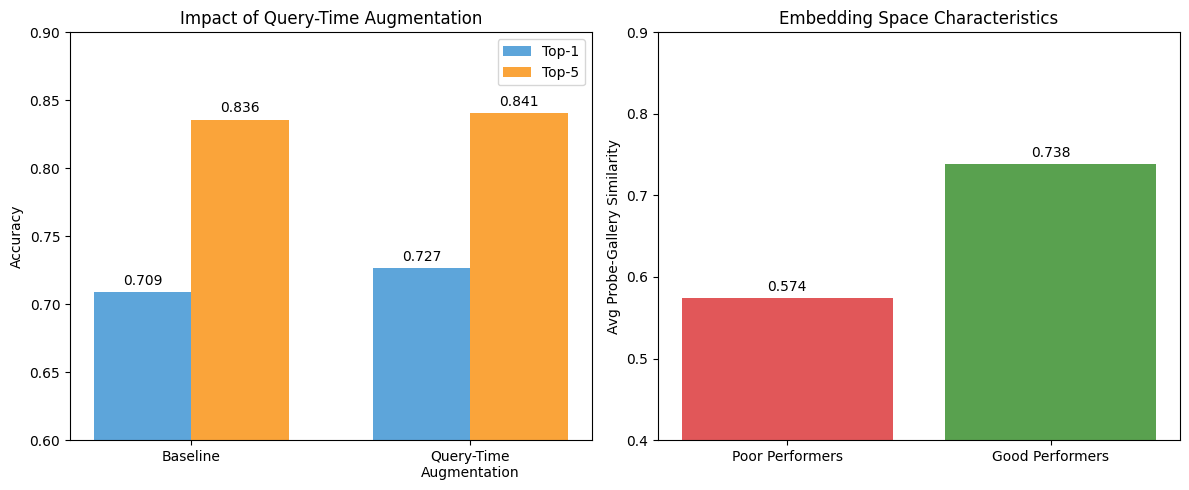

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/uncertainty_analysis.png


In [9]:
import matplotlib.pyplot as plt

figures_dir = BASE_DIR / "analysis" / "figures"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Overall accuracy comparison
ax1 = axes[0]
methods = ['Baseline', 'Query-Time\nAugmentation']
top1_vals = [baseline_top1, augmented_top1]
top5_vals = [baseline_top5, augmented_top5]

x = np.arange(len(methods))
width = 0.35

bars1 = ax1.bar(x - width/2, top1_vals, width, label='Top-1', color='#5DA5DA')
bars2 = ax1.bar(x + width/2, top5_vals, width, label='Top-5', color='#FAA43A')

ax1.set_ylabel('Accuracy')
ax1.set_title('Impact of Query-Time Augmentation')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.set_ylim(0.6, 0.9)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Right plot: Poor vs Good performer characteristics
ax2 = axes[1]
categories = ['Poor Performers', 'Good Performers']
similarities = [poor_avg_sim, good_avg_sim]

bars3 = ax2.bar(categories, similarities, color=['#E15759', '#59A14F'])
ax2.set_ylabel('Avg Probe-Gallery Similarity')
ax2.set_title('Embedding Space Characteristics')
ax2.set_ylim(0.4, 0.9)

for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(figures_dir / "uncertainty_analysis.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'uncertainty_analysis.png'}")

In [10]:
task5_results = {
    "baseline": {"top1": baseline_top1, "top5": baseline_top5},
    "augmented": {"top1": augmented_top1, "top5": augmented_top5},
    "improvement": {"top1": augmented_top1 - baseline_top1, "top5": augmented_top5 - baseline_top5},
    "poor_performers": {
        "count": len(poor_performers),
        "improved": improved_count,
        "still_poor": still_poor_count
    },
    "embedding_analysis": {
        "poor_avg_similarity": poor_avg_sim,
        "good_avg_similarity": good_avg_sim
    },
    "strategy": "Query-Time Augmentation (6 augmented versions averaged)"
}

results_path = BASE_DIR / "analysis" / "task5_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(task5_results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/task5_results.pkl
